# Exercise 1 - Phytoplankton growth

Vivienne Banks
BNKVIV001

1 June 2026

In [12]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [7]:
# Read in the data file
df = pd.read_csv("flynn94.csv")

print(df.head())

   time  cells  biovolume  ammonium  cellC  chl-a
0   0.0   0.04        2.0     1.411   0.60    4.0
1   0.5   0.04        2.2     1.400   0.61    3.0
2   1.0   0.04        2.1     1.383   0.58    3.0
3   1.5   0.04        2.1     1.355    NaN    3.0
4   2.0   0.04        2.1     1.355   0.68    3.0


### AI Prompt:

Hi this is the structure of my data frame. Missing values are labelled NaN. 

time  cells  biovolume  ammonium  cellC  chl-a
0    0.0   0.04        2.0     1.411   0.60    4.0
1    0.5   0.04        2.2     1.400   0.61    3.0
2    1.0   0.04        2.1     1.383   0.58    3.0

Plot the data using python. Can you make plots of cells, biovolume, ammonium, cellC and chl-a against time

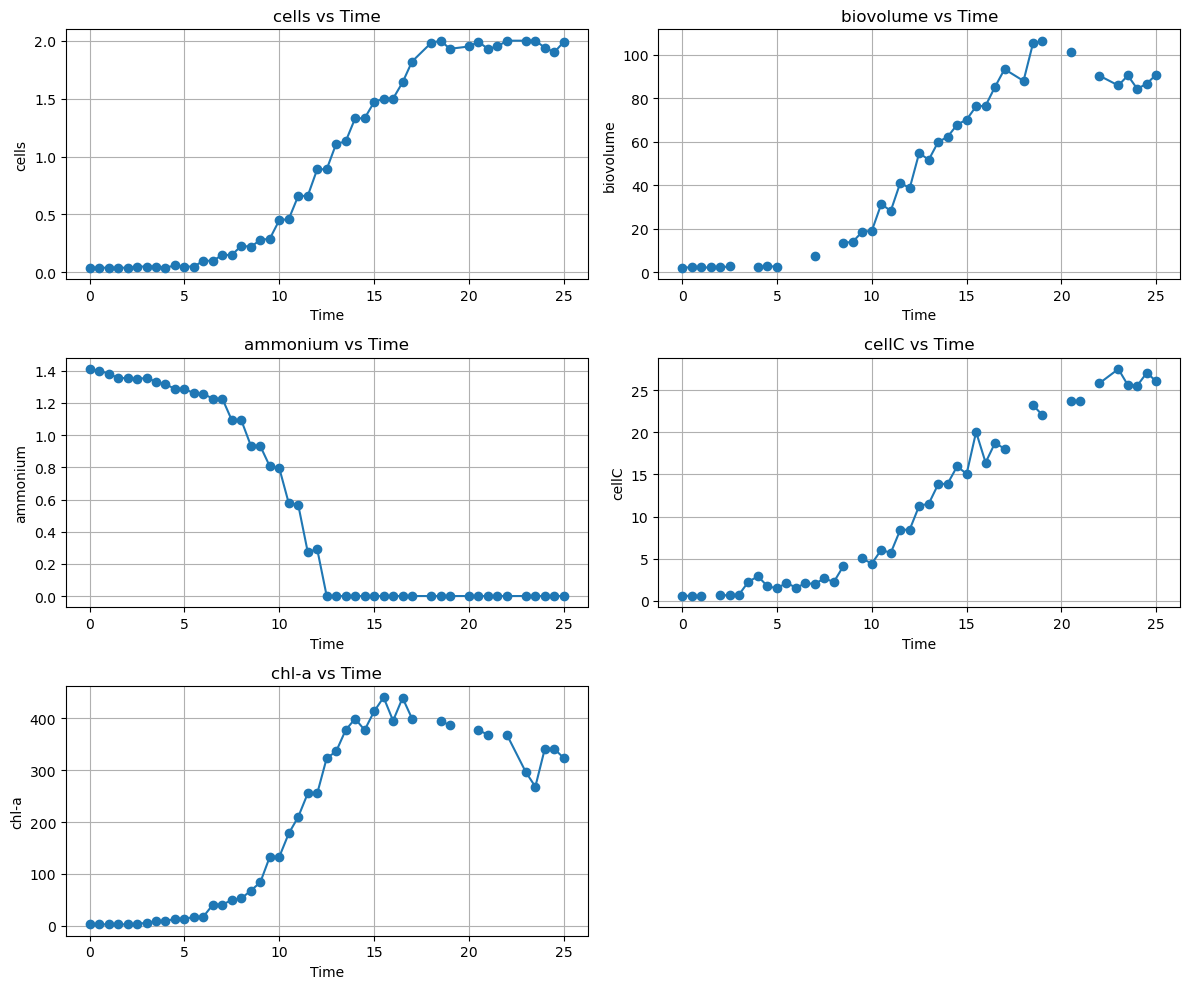

In [8]:
variables = ["cells", "biovolume", "ammonium", "cellC", "chl-a"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    ax.plot(df["time"], df[var], marker="o")
    ax.set_xlabel("Time")
    ax.set_ylabel(var)
    ax.set_title(f"{var} vs Time")
    ax.grid(True)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Question 1: Is the Growth exponential?

The growth is exponential until approximately day 18 when the growth either levels off (cell vs time) or starts declining (biovolume vs time; chl-a vs time). 

Cell Carbon vs time seems to continue with increasing after day 18 although it seems to start slowing down so maybe not purely exponential.

### Question 2: Growth Phases

- Days 1-5: Lag phase, growth is slow to respond to the nutrients.
- Days 6-18: Exponential (Malthusian) Growth; phytoplankton biomass increases rapidly
- Days 18-25: Population decline as nutrient limitation takes effect

### Question 3: Cellular Carbon vs Cell Number and Chlorophyll

Theory:
As nutrient limitation takes effect, cells can still divide but tend to decrease in size (biovolume decreases). Cellular carbon will be more or less maintained as cells continue to divide. Chl-a decreases most strongly as cells experience nutrient stress - that energy is used for other processes.

Theory visualised in the plots:

The number of cells vs time plateus much early at day 18. This is when nutrient limitations start kicking in and they can no longer grow exponenitally but can still divide and maintain their population for a time.

Cellular carbon seems to increase throughout the 25 day period although from approximately day 18, the rate of increase appears to slow down slightly and start to plateau around 25 (fg/cell). This is likely because the phytoplankton are still dividing and thus producing cellular carbon.

Chl-a vs Time shows the same initial exponential pattern but starts declining at day 18. Nutrient limitation takes effect and phytoplankton stop producing more chlorophyll.

The biovolume starts decreasing from ~ day 19 as cells decrease in size in response to nutrient limitations.

### Question 4: Ammonium consumption

Its not exactly an exponential decay since the curve is convex. However, it does mirror an exponential growth but may be approximated by a different equation. The decline in Ammonium starts slowly and increases exponentially until it hits 0. This is inverse to a typical exponential decay which starts decreasing rapidly and then slows down.


### Question 5

AI Prompt: How would you estimate the parameters of the growth curve?

Results:
The AI generated code uses a logistic curve_fit function to find the parameters.
- N0 = 0.005 (initial population size)
- r  = 0.464 (maximum growth rate potential)
- K  = 2.008 (maximum sustainable population size)


From the resulting plot, the growth rate is estimated from the gradient of the exponential section of the curve.
- (actual) Growth rate μ = 0.197


N0 = 0.005
r  = 0.464
K  = 2.008


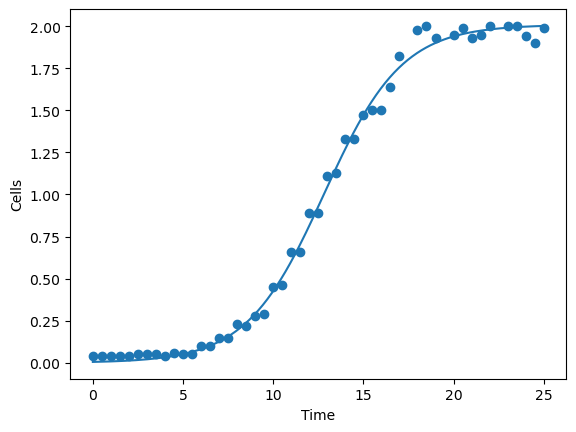

In [10]:


# Data
t = df["time"].values
N = df["cells"].values

# Remove NaNs
mask = np.isfinite(t) & np.isfinite(N)
t = t[mask]
N = N[mask]

# Logistic model
def logistic(t, N0, r, K):
    return K / (1 + ((K - N0)/N0) * np.exp(-r*t))

# Initial guesses
p0 = [
    N[0],        # N0
    0.5,         # r
    np.max(N)    # K
]

# Fit
params, cov = curve_fit(logistic, t, N, p0=p0)

N0_fit, r_fit, K_fit = params

print(f"N0 = {N0_fit:.3f}")
print(f"r  = {r_fit:.3f}")
print(f"K  = {K_fit:.3f}")

# Plot
t_fit = np.linspace(t.min(), t.max(), 200)

plt.scatter(t, N)
plt.plot(t_fit, logistic(t_fit, *params))
plt.xlabel("Time")
plt.ylabel("Cells")
plt.show()

In [13]:
mask = np.isfinite(df["cells"]) & (df["cells"] > 0)

t = df.loc[mask, "time"]
lnN = np.log(df.loc[mask, "cells"])

result = linregress(t, lnN)

mu = result.slope

print(f"Growth rate μ = {mu:.3f}")

Growth rate μ = 0.197


AI Prompt: 
Please plot the growth curve with the following parameters 
- N0 = 0.005 
- r = 0.464 
- K = 2.008 
- Growth rate μ = 0.197

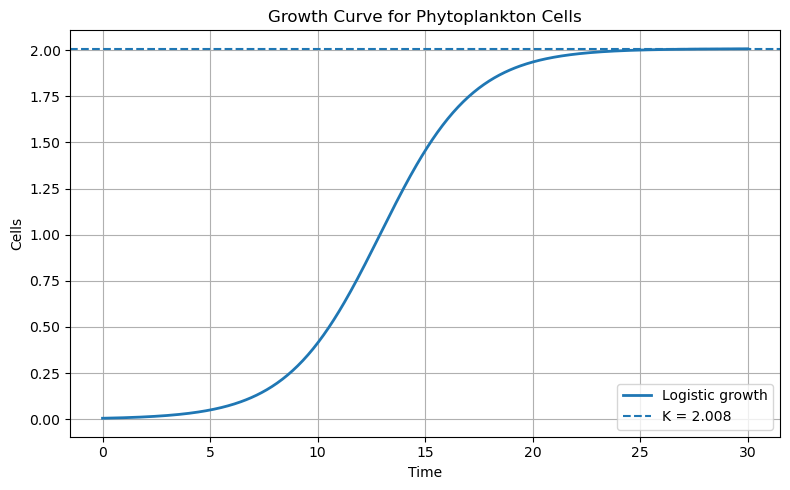

In [15]:
# Parameters
N0 = 0.005
r = 0.464
K = 2.008

# Time vector
t = np.linspace(0, 30, 500)

# Logistic growth function
N = K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(t, N, lw=2, label='Logistic growth')

# Mark carrying capacity
plt.axhline(K, linestyle='--', label=f'K = {K:.3f}')

plt.xlabel('Time')
plt.ylabel('Cells')
plt.title('Growth Curve for Phytoplankton Cells')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()